## **0. Library import**

This section imports the libraries and modules needed to build and evaluate machine learning models. We import pandas for data processing, sklearn for data splitting and normalization, and custom classes from modules in the project such as `DiabetesSGDClassifier`, `DiabetesLogisticRegression`, `DiabetesRandomForest`, and `DiabetesNaiveBayes` to build diabetes prediction models.

In [1]:
import os
import sys
# Add the root path into the python path
root_path = os.path.abspath(os.path.join(".."))
if not root_path in sys.path:
    sys.path.insert(0, root_path)

In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from src.config import BRFSS_FILTERING_FILE_PATH, TRAIN_SIZE, RANDOM_STATE, N_JOBS, \
    SGD_ALPHA, SGD_MAX_ITER, SGD_LOSS, SGD_PENALTY, SGD_LEARNING_RATE, \
    LR_C, LR_PENALTY, LR_CLASS_WEIGHT, LR_VERBOSE, LR_MAX_ITER, LR_SOLVER, \
    RF_N_ESTIMATORS, RF_MAX_DEPTH, \
    NB_ALPHA, NB_TYPE, NB_BINARIZE, NB_VAR_SMOOTHING
from src.evaluate import compare_models
from src.visualization import plot_roc_auc
from src.models import DiabetesSGDClassifier, DiabetesLogisticRegression, DiabetesRandomForest, DiabetesNaiveBayes

## **1. Load dataset**

This section loads the BRFSS dataset that has been processed from the previous data pipeline. From the `df.shape` result, we see that the dataset has size (787,602, 21), which means there are 787,602 records with 21 features. This is a cleaned and normalized dataset, ready for model building.

In [3]:
# Read dataset
df = pd.read_csv(BRFSS_FILTERING_FILE_PATH)
df.shape

(787602, 21)

## **2. Split train and test data**

This part performs the data splitting into training and testing sets. We split the features (X) and target variable (y - Diabetes column) from the original dataset. Then use the parameter `stratify=y` to ensure the ratio of classes in the training and testing sets is the same, avoiding data imbalance. `train_test_split`

The data-splitting results show:

- X_train shape: (629,281, 20)—training set with about 80% of the data
- X_test shape: (158,321, 20)—testing set with about 20% of the data
- y_train and y_test have the same number as X

This ensures that we have enough data to train complex models and still have a reliable test set to evaluate.

In [4]:
# Get features and label from original dataset
X = df.drop("Diabetes", axis=1)
y = df["Diabetes"]

In [5]:
# Split training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=TRAIN_SIZE, random_state=RANDOM_STATE, stratify=y)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (630081, 20)
X_test shape: (157521, 20)
y_train shape: (630081,)
y_test shape: (157521,)


## **3. Data normalization**

This section normalizes the data using MinMaxScaler to bring all features to the same value range [0,1]. This is important because:

The features in the dataset have different scales (BMI from 12 to 99, Age from 1 to 13, binary features 0–1, etc.). Without normalization, the large features will dominate the learning process of algorithms such as SGD and Logistic Regression.

The MinMaxScaler is fitted on the training set and then transforms both the training and testing sets. This ensures that there is no data leakage from the test set into the normalization process.

In [ ]:
# Normalize training and testing features
min_max_scaler = MinMaxScaler()
X_train_normalized = min_max_scaler.fit_transform(X=X_train)
X_test_normalized = min_max_scaler.transform(X=X_test)

In [7]:
X_train_normalized[0]

array([0.        , 1.        , 1.        , 0.1954023 , 1.        ,
       0.        , 0.        , 1.        , 0.        , 0.01010101,
       0.        , 0.5       , 0.1       , 0.        , 0.        ,
       0.        , 0.66666667, 1.        , 0.7       , 0.        ])

## **3. Models**

This section builds and evaluates four different machine learning models on the same dataset to compare their performance.

### **3.1 SGD Classifier**

Stochastic Gradient Descent Classifier is an optimization algorithm suitable for large datasets such as BRFSS with nearly 800K records. The model is initialized with hyperparameters from the config file and logged into . `../logs/og_sgd_classifier.log`
From the training and evaluation process, SGD Classifier shows:

- Ability to handle large datasets well with fast training speed
- Cross-validation results show the stability of the model through different folds
- ROC-AUC plot helps evaluate the ability to distinguish between classes, especially important for multi-class problems such as diabetes

In [8]:
# Initialize an SGDClassifier model for BRFSS dataset and get model information
sgd_model = DiabetesSGDClassifier(
    loss=SGD_LOSS,
    penalty=SGD_PENALTY,
    alpha=SGD_ALPHA,
    max_iter=SGD_MAX_ITER,
    random_state=RANDOM_STATE,
    learning_rate=SGD_LEARNING_RATE,
    n_jobs=N_JOBS,
    log_file="../logs/og_sgd_classifier.log",
)

# Get the model information
sgd_model_info = sgd_model.get_model_info()

2025-07-27 04:48:39,901 - [src.models] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-07-27 04:48:39,902 - [src.models] - INFO -   loss: log_loss
2025-07-27 04:48:39,902 - [src.models] - INFO -   penalty: l2
2025-07-27 04:48:39,902 - [src.models] - INFO -   alpha: 0.0001
2025-07-27 04:48:39,903 - [src.models] - INFO -   learning_rate: constant
2025-07-27 04:48:39,903 - [src.models] - INFO -   eta0: 0.01
2025-07-27 04:48:39,904 - [src.models] - INFO -   max_iter: 1000
2025-07-27 04:48:39,904 - [src.models] - INFO -   random_state: 42


In [9]:
# Model information
sgd_model_info

{'loss': 'log_loss',
 'penalty': 'l2',
 'alpha': 0.0001,
 'learning_rate': 'constant',
 'eta0': 0.01,
 'max_iter': 1000,
 'random_state': 42,
 'model_path': None,
 'is_fitted': False}

In [ ]:
# Train model with original dataset
sgd_model.train(
    X=X_train_normalized, 
    y=y_train
)

2025-07-27 04:48:40,045 - [src.models] - INFO - Starting SGD Classifier model training...
2025-07-27 04:48:41,358 - [src.models] - INFO - Model training completed. Training samples: 630081
2025-07-27 04:48:41,359 - [src.models] - INFO - Number of iterations: 7


In [ ]:
# Predict on the testing set
sgd_y_pred = sgd_model.predict(X=X_test_normalized)

2025-07-27 04:48:41,398 - [src.models] - INFO - Predictions made for 157521 samples


In [12]:
# The 10 first predicted results
sgd_y_pred[:10]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
# Evaluate SGDClassifier model
sgd_model_eval_results = sgd_model.evaluate(y_true=y_test, y_pred=sgd_y_pred)

2025-07-27 04:48:41,629 - [src.models] - INFO - Model Evaluation Results:
2025-07-27 04:48:41,630 - [src.models] - INFO - Accuracy: 0.8400
2025-07-27 04:48:41,630 - [src.models] - INFO - Precision: 0.4605
2025-07-27 04:48:41,630 - [src.models] - INFO - Recall: 0.3921
2025-07-27 04:48:41,630 - [src.models] - INFO - F1-Score: 0.4023
2025-07-27 04:48:41,679 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91    131574
         1.0       0.00      0.00      0.00      3393
         2.0       0.52      0.21      0.30     22554

    accuracy                           0.84    157521
   macro avg       0.46      0.39      0.40    157521
weighted avg       0.79      0.84      0.80    157521

2025-07-27 04:48:41,725 - [src.models] - INFO - Confusion Matrix:
[[127671      0   3903]
 [  3048      0    345]
 [ 17906      0   4648]]


In [14]:
# Evaluation results
sgd_model_eval_results

{'accuracy': 0.8400086337694657,
 'precision': 0.4604987707058911,
 'recall': 0.3921397542623332,
 'f1_score': 0.40228944500650554}

In [ ]:
# Predict class probabilities
sgd_prob = sgd_model.predict_proba(X=X_train_normalized)

2025-07-27 04:48:41,915 - [src.models] - INFO - Probabilities predicted for 630081 samples


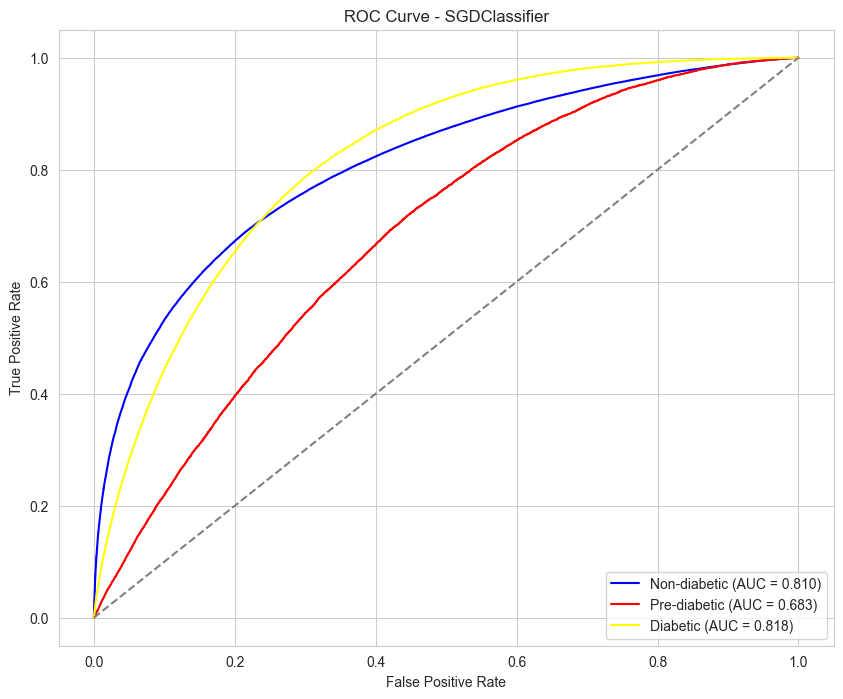

In [ ]:
# Plot ROC and AUC
plot_roc_auc(
    y_true=y_train, 
    y_pred_proba=sgd_prob, 
    model_name="SGDClassifier"
)

In [ ]:
# Evaluate SGDClassifier model with cross-validation
sgd_model_cv_scores = sgd_model.cross_validate(X=X_train_normalized, y=y_train)
sgd_model_cv_scores

2025-07-27 04:48:49,046 - [src.models] - INFO - Cross-validation results:
2025-07-27 04:48:49,046 - [src.models] - INFO - Mean accuracy: 0.8402 (+/- 0.0013)


array([0.83996604, 0.8408218 , 0.84025838, 0.8390998 , 0.84097257])

### **3.2 Logistic Regression**

Logistic Regression is a classic and effective algorithm for classification problems, especially suitable for medical data because of its good interpretability. The model is configured with optimal parameters and logged into . `../logs/og_logistic_regression.log`

Strengths of Logistic Regression in the diabetes problem:

- Provides clear probability estimates for each class
- Coefficients are interpretable, helping to understand the relationship between features and targets
- Stable and less prone to overfitting with large datasets

In [18]:
# Initialize a LogisticRegression model and get model information
lr_model = DiabetesLogisticRegression(
    C=LR_C, 
    penalty=LR_PENALTY, 
    class_weight=LR_CLASS_WEIGHT,
    max_iter=LR_MAX_ITER, 
    solver=LR_SOLVER,
    random_state=RANDOM_STATE,
    verbose=LR_VERBOSE,
    n_jobs=N_JOBS,
    log_file="../logs/og_logistic_regression.log"
    
)
lr_model_info = lr_model.get_model_info()

2025-07-27 04:48:49,801 - [src.models] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-07-27 04:48:49,802 - [src.models] - INFO -   C: 1.0
2025-07-27 04:48:49,803 - [src.models] - INFO -   penalty: l2
2025-07-27 04:48:49,803 - [src.models] - INFO -   class_weight: None
2025-07-27 04:48:49,804 - [src.models] - INFO -   solver: saga
2025-07-27 04:48:49,805 - [src.models] - INFO -   max_iter: 100
2025-07-27 04:48:49,806 - [src.models] - INFO -   random_state: 42


In [19]:
# Model information
lr_model_info

{'C': 1.0,
 'penalty': 'l2',
 'solver': 'saga',
 'max_iter': 100,
 'random_state': 42,
 'model_path': None}

In [ ]:
# Train model
lr_model.train(X=X_train_normalized, y=y_train)

2025-07-27 04:48:49,973 - [src.models] - INFO - Starting Logistic Regression model training...
2025-07-27 04:48:58,056 - [src.models] - INFO - Model training completed. Training samples: 630081


In [ ]:
# Predict on the testing set
lr_y_pred = lr_model.predict(X=X_test_normalized)

2025-07-27 04:48:58,099 - [src.models] - INFO - Predictions made for 157521 samples


In [22]:
# The 10 first predicted results
lr_y_pred[:10]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
# Evaluate LogisticRegression model
lr_model_eval_results = lr_model.evaluate(y_true=y_test, y_pred=lr_y_pred)

2025-07-27 04:48:58,342 - [src.models] - INFO - Model Evaluation Results:
2025-07-27 04:48:58,343 - [src.models] - INFO - Accuracy: 0.8412
2025-07-27 04:48:58,343 - [src.models] - INFO - Precision: 0.4663
2025-07-27 04:48:58,344 - [src.models] - INFO - Recall: 0.3864
2025-07-27 04:48:58,345 - [src.models] - INFO - F1-Score: 0.3955
2025-07-27 04:48:58,394 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.91    131574
         1.0       0.00      0.00      0.00      3393
         2.0       0.54      0.18      0.27     22554

    accuracy                           0.84    157521
   macro avg       0.47      0.39      0.40    157521
weighted avg       0.79      0.84      0.80    157521

2025-07-27 04:48:58,450 - [src.models] - INFO - Confusion Matrix:
[[128365      0   3209]
 [  3107      0    286]
 [ 18412      0   4142]]


In [24]:
# Evaluation results
lr_model_eval_results

{'accuracy': 0.8412021254308949,
 'precision': 0.4662628456708222,
 'recall': 0.38641960544349435,
 'f1_score': 0.3955098679179389}

In [ ]:
# Predict class probabilities
lr_prob = lr_model.predict_proba(X=X_train_normalized)

2025-07-27 04:48:58,672 - [src.models] - INFO - Probabilities predicted for 630081 samples


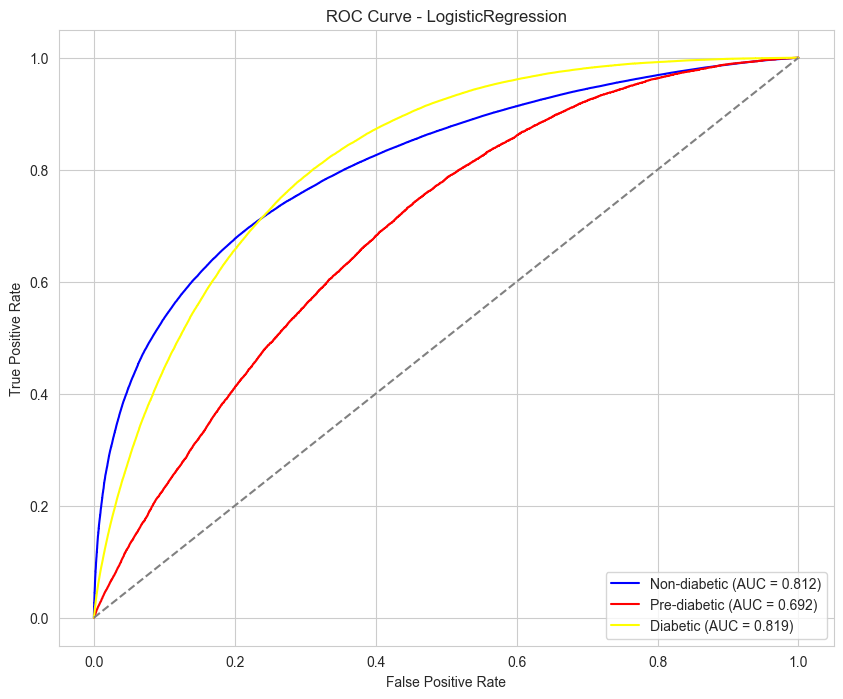

In [ ]:
# Plot ROC and AUC
plot_roc_auc(
    y_true=y_train, 
    y_pred_proba=lr_prob, 
    model_name="LogisticRegression"
)

In [ ]:
# Evaluate Logistic Regression with cross-validation
lr_model_cv_scores = lr_model.cross_validate(X=X_train_normalized, y=y_train)
lr_model_cv_scores

2025-07-27 04:49:31,867 - [src.models] - INFO - Cross-validation results:
2025-07-27 04:49:31,868 - [src.models] - INFO - Mean accuracy: 0.8406 (+/- 0.0009)


array([0.83999778, 0.84049644, 0.84076625, 0.84036154, 0.84138522])

### **3.3 Naive Bayes**

Naive Bayes is a probabilistic algorithm based on Bayes theorem, suitable for features with conditional independence. The model is log-in and uses Gaussian variant suitable for continuous features such as BMI, MentHlth, PhysHlth. `../logs/og_naive_bayes.log`

Characteristics of Naive Bayes in this context:

- Training is rapid and memory-efficient
- Works well even with small training data
- Robust with noisy data and irrelevant features
- Provides probabilistic predictions useful for medical diagnosis

In [28]:
# Initialize a NaiveBayes model and get model information
nb_model = DiabetesNaiveBayes(
    nb_type=NB_TYPE,
    var_smoothing=NB_VAR_SMOOTHING,
    binarize=NB_BINARIZE,
    alpha=NB_ALPHA,
    log_file="../logs/og_naive_bayes.log"
)
nb_model_info = nb_model.get_model_info()

2025-07-27 04:49:31,987 - [src.models] - INFO - DiabetesNaiveBayes (Gaussian) initialized with parameters:
2025-07-27 04:49:31,988 - [src.models] - INFO -   nb_type: gaussian
2025-07-27 04:49:31,990 - [src.models] - INFO -   var_smoothing: 1e-09


In [29]:
# Model information
nb_model_info

{'nb_type': 'gaussian',
 'var_smoothing': 1e-09,
 'model_path': None,
 'is_fitted': False}

In [ ]:
# Train model
nb_model.train(X=X_train_normalized, y=y_train)

2025-07-27 04:49:32,192 - [src.models] - INFO - Starting Gaussian Naive Bayes model training...
2025-07-27 04:49:32,371 - [src.models] - INFO - Model training completed. Training samples: 630081
2025-07-27 04:49:32,372 - [src.models] - INFO - Number of classes: 3
2025-07-27 04:49:32,373 - [src.models] - INFO - Classes: [0. 1. 2.]


In [ ]:
# Predict on the testing set
nb_y_pred = nb_model.predict(X=X_test_normalized)

2025-07-27 04:49:32,473 - [src.models] - INFO - Predictions made for 157521 samples


In [32]:
# The 10 first predicted results
nb_y_pred[:10]

array([0., 2., 0., 0., 2., 0., 0., 0., 0., 0.])

In [ ]:
# Evaluate NaiveBayes model
nb_model_eval_results = nb_model.evaluate(y_true=y_test, y_pred=nb_y_pred)

2025-07-27 04:49:32,647 - [src.models] - INFO - Model Evaluation Results:
2025-07-27 04:49:32,648 - [src.models] - INFO - Accuracy: 0.7547
2025-07-27 04:49:32,648 - [src.models] - INFO - Precision: 0.4246
2025-07-27 04:49:32,649 - [src.models] - INFO - Recall: 0.4643
2025-07-27 04:49:32,649 - [src.models] - INFO - F1-Score: 0.4297
2025-07-27 04:49:32,700 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.80      0.85    131574
         1.0       0.04      0.01      0.02      3393
         2.0       0.33      0.58      0.42     22554

    accuracy                           0.75    157521
   macro avg       0.42      0.46      0.43    157521
weighted avg       0.80      0.75      0.77    157521

2025-07-27 04:49:32,754 - [src.models] - INFO - Confusion Matrix:
[[105833    735  25006]
 [  1939     40   1414]
 [  9320    225  13009]]


In [34]:
# Evaluation results
nb_model_eval_results

{'accuracy': 0.754705721776779,
 'precision': 0.42459321983465675,
 'recall': 0.46431449824099674,
 'f1_score': 0.429725694047517}

In [ ]:
# Predict class probabilities
nb_prob = nb_model.predict_proba(X=X_train_normalized)

2025-07-27 04:49:33,155 - [src.models] - INFO - Probabilities predicted for 630081 samples


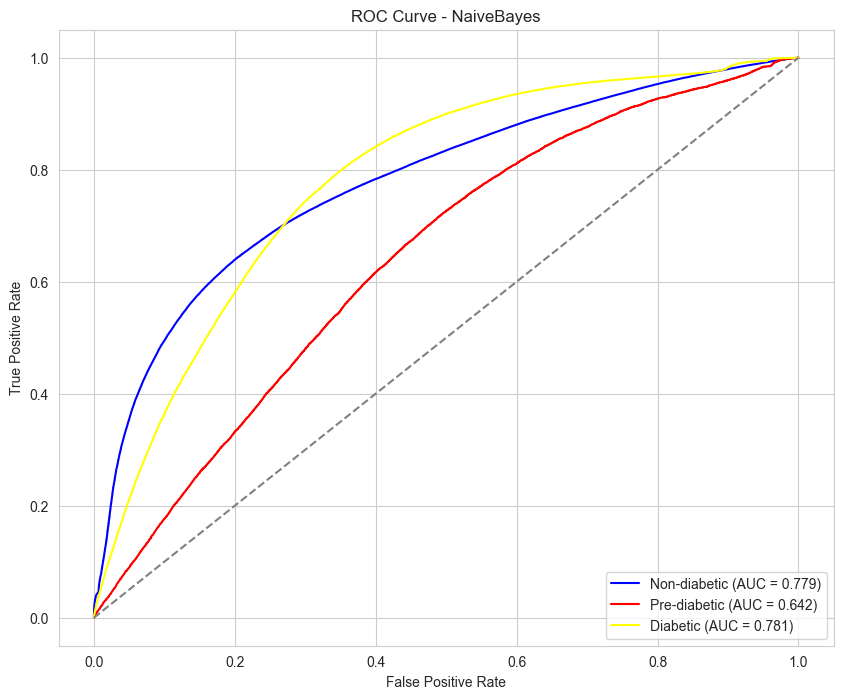

In [ ]:
# Plot ROC and AUC
plot_roc_auc(
    y_true=y_train, 
    y_pred_proba=nb_prob, 
    model_name="NaiveBayes"
)

In [ ]:
# Evaluate Naive Bayes with cross-validation
nb_model_cv_scores = nb_model.cross_validate(X=X_train_normalized, y=y_train)
nb_model_cv_scores

2025-07-27 04:49:35,272 - [src.models] - INFO - Cross-validation results:
2025-07-27 04:49:35,273 - [src.models] - INFO - Mean accuracy: 0.7522 (+/- 0.0030)


array([0.75200171, 0.75406298, 0.74990477, 0.75159504, 0.7535313 ])

### **3.4 Random Forest**

Random Forest is an ensemble method that combines multiple decision trees, often giving high accuracy and less overfitting. The model is configured with the appropriate number of estimators and max_depth, log in . `../logs/og_random_forest.log`

Advantages of Random Forest for medical data:

- Handle different types of features (continuous, categorical) without much preprocessing
- Provide feature importance rankings, helping to understand which features are most important for prediction
- Robust with outliers (BMI has max=99 in the dataset)
- Automatically handle missing values and feature interactions

In [38]:
# Initialize a RandomForest model and get model information
rf_model = DiabetesRandomForest(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    random_state=RANDOM_STATE,
    log_file="../logs/og_random_forest.log"
)
rf_model_info = rf_model.get_model_info()

2025-07-27 04:49:35,323 - [src.models] - INFO - DiabetesRandomForest initialized with parameters:
2025-07-27 04:49:35,323 - [src.models] - INFO -   n_estimators: 100
2025-07-27 04:49:35,324 - [src.models] - INFO -   max_depth: 25
2025-07-27 04:49:35,324 - [src.models] - INFO -   min_samples_split: 2
2025-07-27 04:49:35,324 - [src.models] - INFO -   min_samples_leaf: 1
2025-07-27 04:49:35,324 - [src.models] - INFO -   max_features: sqrt
2025-07-27 04:49:35,325 - [src.models] - INFO -   random_state: 42


In [39]:
# Model information
rf_model_info

{'n_estimators': 100,
 'max_depth': 25,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'random_state': 42,
 'model_path': None}

In [ ]:
# Train model
rf_model.train(X=X_train_normalized, y=y_train)

2025-07-27 04:49:35,517 - [src.models] - INFO - Starting Random Forest model training...
2025-07-27 04:50:33,245 - [src.models] - INFO - Model training completed. Training samples: 630081
2025-07-27 04:50:33,246 - [src.models] - INFO - Number of trees: 100


In [ ]:
# Predict on the testing set
rf_y_pred = rf_model.predict(X=X_test_normalized)

2025-07-27 04:50:37,274 - [src.models] - INFO - Predictions made for 157521 samples


In [42]:
# The 10 first predicted results
rf_y_pred[:10]

array([0., 2., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
# Evaluate RandomForest model
rf_model_eval_results = rf_model.evaluate(y_true=y_test, y_pred=rf_y_pred)

2025-07-27 04:50:37,458 - [src.models] - INFO - Model Evaluation Results:
2025-07-27 04:50:37,459 - [src.models] - INFO - Accuracy: 0.8402
2025-07-27 04:50:37,459 - [src.models] - INFO - Precision: 0.5454
2025-07-27 04:50:37,460 - [src.models] - INFO - Recall: 0.3886
2025-07-27 04:50:37,460 - [src.models] - INFO - F1-Score: 0.3985
2025-07-27 04:50:37,510 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91    131574
         1.0       0.25      0.00      0.00      3393
         2.0       0.53      0.19      0.28     22554

    accuracy                           0.84    157521
   macro avg       0.55      0.39      0.40    157521
weighted avg       0.80      0.84      0.80    157521

2025-07-27 04:50:37,563 - [src.models] - INFO - Confusion Matrix:
[[128041     13   3520]
 [  3076      6    311]
 [ 18246      5   4303]]


In [44]:
# Evaluation results
rf_model_eval_results

{'accuracy': 0.8402054329264035,
 'precision': 0.5454203748786223,
 'recall': 0.3885676978920784,
 'f1_score': 0.3984918030720328}

In [ ]:
# Predict class probabilites
rf_prob = rf_model.predict_proba(X=X_train_normalized)

2025-07-27 04:50:53,401 - [src.models] - INFO - Probabilities predicted for 630081 samples


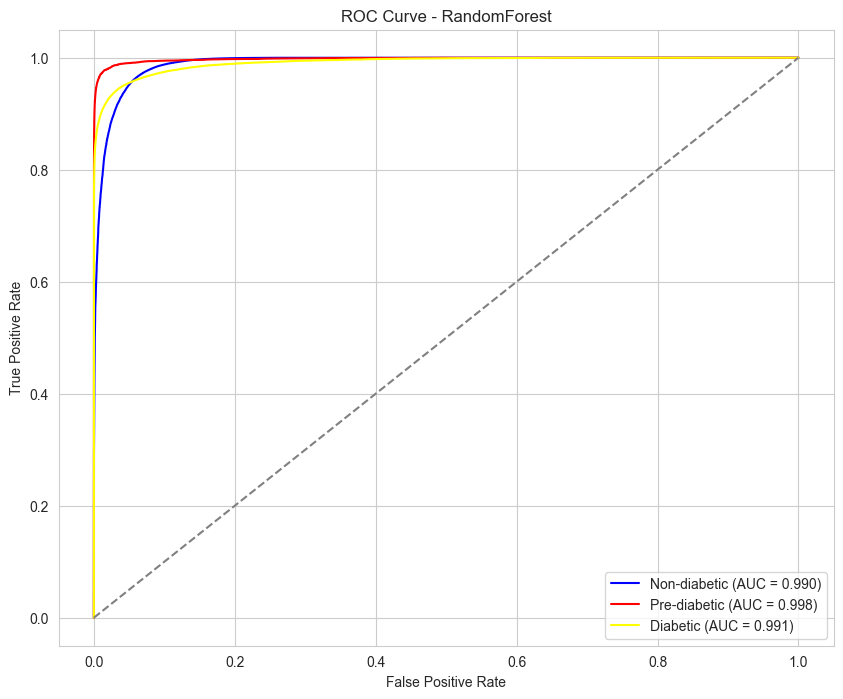

In [ ]:
# Plot ROC and AUC
plot_roc_auc(
    y_true=y_train, 
    y_pred_proba=rf_prob, 
    model_name="RandomForest"
)

In [ ]:
# Evaluate Random Forest with cross-validation
rf_model_cv_scores = rf_model.cross_validate(X=X_train_normalized, y=y_train)
rf_model_cv_scores

2025-07-27 04:54:54,726 - [src.models] - INFO - Cross-validation results:
2025-07-27 04:54:54,727 - [src.models] - INFO - Mean accuracy: 0.8397 (+/- 0.0007)


array([0.83983113, 0.83971083, 0.83952038, 0.83913947, 0.84015522])

## **4. Compare models**

This final section compares the performance of all four models on the same test set to determine which model is the best. This comparison includes:
**Metrics compared:**
- Accuracy: Overall correct prediction rate
- Precision: Accuracy of positive predictions
- Recall: Ability to detect positive cases
- F1-score: Harmonic mean of precision and recall

**Meaning in the medical context:**
- High recall is important to avoid missing diabetes cases (dangerous false negatives)
- High precision helps avoid over-diagnosis (costly false positives)
- Balanced F1-score for good overall performance

From the comparison results, we can determine:
- Which model is best suited for the diabetes prediction problem?
- Trade-offs between different metrics
- Recommendations for real-world deployments

This result will be the foundation for deciding whether to apply techniques such as feature engineering, data balancing, or hyperparameter tuning in later experiments.

2025-07-27 04:54:54,842 - [src.models] - INFO - Predictions made for 157521 samples
2025-07-27 04:54:54,869 - [src.models] - INFO - Probabilities predicted for 157521 samples
2025-07-27 04:54:55,144 - [src.models] - INFO - Predictions made for 157521 samples
2025-07-27 04:54:55,171 - [src.models] - INFO - Probabilities predicted for 157521 samples
2025-07-27 04:54:55,470 - [src.models] - INFO - Predictions made for 157521 samples
2025-07-27 04:54:55,528 - [src.models] - INFO - Probabilities predicted for 157521 samples
2025-07-27 04:54:59,810 - [src.models] - INFO - Predictions made for 157521 samples
2025-07-27 04:55:03,806 - [src.models] - INFO - Probabilities predicted for 157521 samples


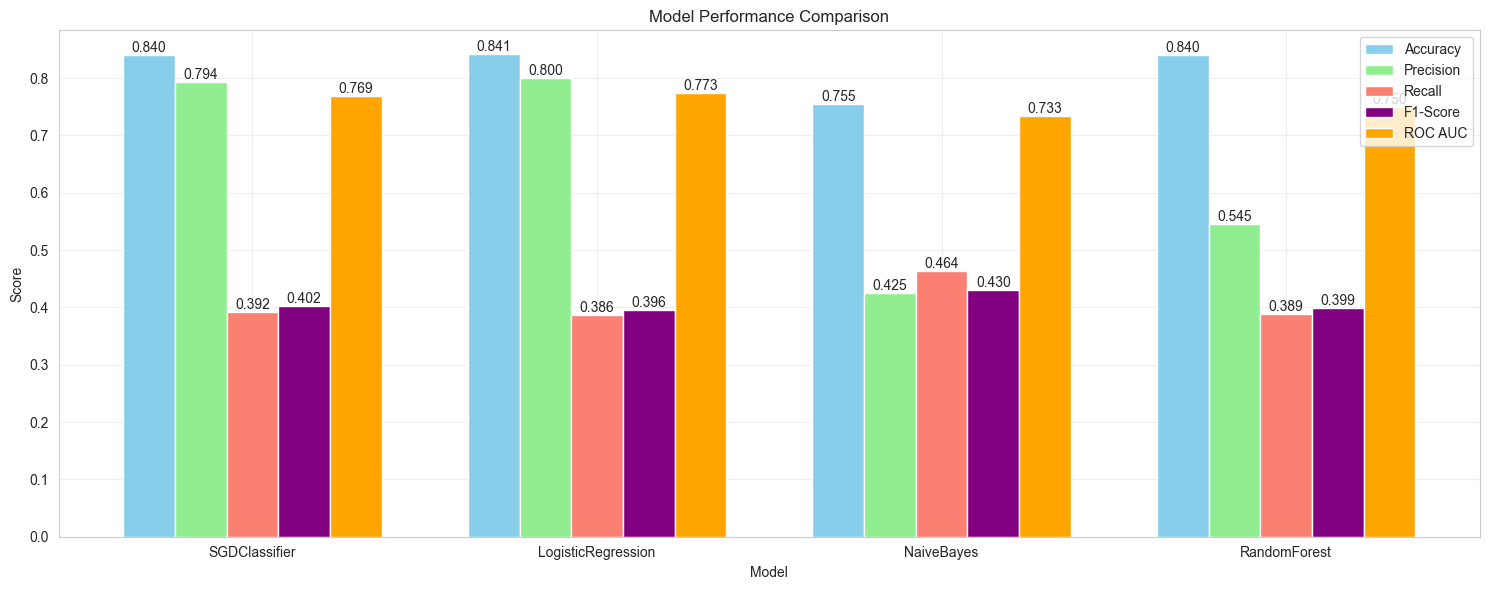

In [ ]:
# Compare validation results of each model
models = {
    "SGDClassifier": sgd_model,
    "LogisticRegression": lr_model,
    "NaiveBayes": nb_model,
    "RandomForest": rf_model
}
comparison_results = compare_models(
    models_dict=models, 
    X_test=X_test_normalized, 
    y_true=y_test
)

In [49]:
# Comparison results
comparison_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2
0,SGDClassifier,0.8400,0.7938,0.3921,0.4023,0.7693,0.8590,1.00,0.5225,0.9703,0.0000,0.2061,0.9113,0.0000,0.2956
1,LogisticRegression,0.8412,0.7996,0.3864,0.3955,0.7733,0.8564,1.00,0.5424,0.9756,0.0000,0.1836,0.9121,0.0000,0.2744
2,NaiveBayes,0.7547,0.4246,0.4643,0.4297,0.7332,0.9038,0.04,0.3299,0.8044,0.0118,0.5768,0.8512,0.0182,0.4198
3,RandomForest,0.8402,0.5454,0.3886,0.3985,0.7495,0.8572,0.25,0.5290,0.9731,0.0018,0.1908,0.9115,0.0035,0.2804
